<a href="https://colab.research.google.com/github/GabrielaRguezCampos/Heat_equation_time_dependent_solution/blob/main/Final_Report_Heat_Equation_Group_Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from IPython.display import HTML
HTML('<style>@media print { .output_png { page-break-inside: avoid; } }</style>')

# Final Report: Model for heat flow based on the steady reaction-diffusion equation

Ismael Morell

Anthony Rodriguez

Gabriela Rodriguez

## Problem Statement
$$\frac{\partial ^2 u}{\partial x ^2} + \frac{\partial ^2 u}{\partial y ^2} + ku(x,y) + f(x,y) = 0  \  (*)$$

The purpose of this project is to approximate solutions to the steady state heat-diffusion equation (*) by converting the continuous problem into a discrete one and using two iterative methods to solve the resulting system of linear equations.

We analyze convergence rates of the Jacobi method and the Gauss-Seidel method in solving these systems of linear equations.

Finally, we visualize our solutions to equation (*) using heatmaps.

## Unraveling the Steady State Heat-Diffusion Equation

 ### Term 1: The Laplacian
 $$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}$$
The Laplacian operator measures how the temperature at a point compares to the average temperature of its neighboring points. Physically, this represents heat diffusion, the natural tendency of heat to flow from hot regions to cold regions.

If a point is hotter than its neighbors, the Laplacian is negative, indicating heat flows away from that point
If a point is colder than its neighbors, the Laplacian is positive, indicating heat flows toward that point
At thermal equilibrium, these flows balance out

This is a direct consequence of Fourier's Law of Heat Conduction, which states that heat flux is proportional to the negative temperature gradient.

 ### Term 2: The Reaction Term
 $$ku(x,y)$$
The term ku models heat exchange with the environment or internal heat generation:

When k < 0 (Cooling/Heat Loss): This represents Newton's Law of Cooling, where the plate loses heat to the surrounding environment. The rate of heat loss is proportional to the temperature, hotter regions lose heat faster. This pulls temperatures toward zero (the ambient temperature in our normalized model). In our experiments, k = -1 represents strong environmental cooling.

When k > 0 (Exothermic Reaction): This represents internal heat generation, such as from a chemical reaction occurring within the material. Higher temperatures accelerate the reaction, generating more heat. In our experiments, k = 0.01 represents mild heat generation. Note: Large positive values of k can lead to thermal runaway or numerical instabilities.

When k = 0 (Laplace Equation): With no reaction term, we have the classical Laplace equation, representing pure heat diffusion with no heat exchange with the environment.

### Term 3: The Source Term
$$f(x,y)$$
The function f(x,y) represents internal heat sources or sinks at specific locations within the plate:

f(x,y) > 0: Heat is being generated at point (x,y) — like a heating element

f(x,y) < 0: Heat is being absorbed at point (x,y) — like a cooling element

f(x,y) = 0: No internal heat source at that location

## Step 1: Discretizing the problem

To find an approximate solution to equation (*) , we employ
a finite difference method. First we superimpose a square grid on the metal plate with uniform spacing, labeling the points on the grid
$(x_i, y_j)$ and the value of u at these points $u(x_i, y_j)$ = $U_{i,j}$ and the value of f by $f(x_i, y_j)$ = $f_{i,j}$. We assume the gridpoints are unit distance apart for simplicity.

The second derivatives in (\*), i.e. the Laplacian operator of u, can be approximated by the discrete Laplacian operator applied to u. This gives us the following discretization of (\*) for each point $(x_i, y_j)$ of our grid:

$$(-4+k)U_{i,j} + U_{i+1,j} + U_{i-1,j} + U_{i,j+1} + U_{i,j-i} = -f_{i,j}  \ (**)$$

This is the system of equations we solve in order to find our temperature distribution u. We turn the system of $n^2$ linear equations (**) into a matrix equation as follows.

Assuming the interior of our grid is nxn, we can flatten it into a vector containing the temperature at every point of our grid by putting each row of our grid end to end:

$$\vec{u} =
\begin{bmatrix}
U_{1,1} & U_{1,2} & ... &U_{1,n} & | & U_{2,1} & ... & U_{2,n} & |  & ... & U_{n,n}
\end{bmatrix}^T$$

Note that if any neighbor to $U_{i,j}$ is a boundary point, we can move those known boundary values of u to the other side of (\*\*). Doing this allows us to write the system of equations given by (\*\*) as a matrix equation:

$$A\vec{u} = - \vec{b} - \vec{f} \ (***)$$

Let’s look at equation (\*\*\*) in more detail. The right hand of the equation comes from terms in the system of equations (\*\*) which are known and have been moved to the right hand side, i.e. the values of f at each point of our grid and any contributions from border gridpoints. The vector b represents the border contributions. We can write the vectors f and b as follows, note that f has the same structure as u:

$$\vec{f} =
\begin{bmatrix}
f_{1,1} & f_{1,2} & ... &f_{1,n} & |  & f_{2,1} & ... & f_{2,n} & |  & ... & f_{n,n}
\end{bmatrix}^T$$

$$\vec{b} =
\begin{bmatrix}
200 & 100 & ... &100 & 200 & |  & 100 & 0 & ... & 0 & 100 & | ...| & 200 &  ... & 200
\end{bmatrix}^T$$

The matrix A from our matrix equation (\*\*\*) contains the coefficients of the left side of the system of linear equations (\*\*). It is an $n^2 * n^2$ sparse block matrix involving n copies of another matrix B along its main diagonal and n-1 copies of the nxn identity matrix along the diagonal directly above the main diagonal and similarly for the diagonal directly below it. Matrix B is nxn. A and B are defined as follows, with blank spaces corresponding to 0's:  

$$ A =
\begin{bmatrix}
B & I \\
I & B & I \\
 & I  & \ddots & \ddots \\
&   & \ddots & \ddots  & I\\
& & & I & B
\end{bmatrix}$$

$$B =
\begin{bmatrix}
(-4+k) & 1 \\
1 & (-4+k) & 1 \\
 & 1  & \ddots & \ddots \\
&   & \ddots & \ddots  & 1\\
& & & 1 & (-4+k)
\end{bmatrix}$$


We will now look at the code that converts (*) into its discretized matrix form.

##Creating Heat Equation Matrix Form

In [ ]:
import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

#Creating utility functions to create sparse matrices

def create_large_diagonal_matrix(n, k):
  """
  Make sparse block diagonal matrix of B's to later create matrix A.

  parameters:
        n (int): sqrt of number of gridpoints in our model
        k (float): parameter representing cooling/exothermic reaction

  returns:
        block_diag (array-like): (n**2)x(n**2) array to later convert to A

  """
  #Set diagonal values
  diagonals = [np.ones(n-1), (k-4)*np.ones(n),np.ones(n-1)]
  #Set diagonal offsets
  offsets = [-1,0,1]
  #Create and return sparse block matrix
  B = sparse.diags(diagonals, offsets, shape=(n,n))
  return sparse.block_diag([B]*n)

def create_large_ones_matrix(n):
  """
  Make sparse matrix of 1's to later create matrix A.

  parameters:
        n (int): sqrt of number of gridpoints in our model

  returns:
        sparse_matrix (array-like): (n**2)x(n**2) array to later create matrix A
  """
  #Set diagonal values
  diagonals = [np.ones(n**2-n), np.ones(n**2-n)]
  #Set diagonal offsets
  offsets = [-n,n]
  return sparse.diags(diagonals, offsets, shape=(n**2, n**2))

def create_large_matrix(n, k):
  """
  Make matrix A for the matrix equation Au = -b - f.

  parameters:
        n (int): sqrt of number of gridpoints in our model
        k (float): parameter representing cooling/exothermic reaction

  returns:
        A (array-like): (n**2)x(n**2) array A for matrix equation Au = -b - f
  """
  #Create large diagonal matrix of B's
  A = create_large_diagonal_matrix(n,k)
  #Add off diagonals of 1's
  A += create_large_ones_matrix(n)
  return A

def create_border_contribution_vector(n, border_temp):
  """
  Create border contribution vector b for the matrix equation Au = -b - f.

  parameters:
        n (int): sqrt of number of gridpoints in our model
        border_temp (float): float representing the temperature of the border

  returns:
        b (array-like): (n**2)x1 array b for matrix equation Au = -b - f
  """

  #Create nxn matrix representing border contributions for each gridpoint
  b = np.zeros((n,n))

  #Set contribution from top and bottom of border
  b[0] = (border_temp)*np.ones(n)
  b[n-1] = (border_temp)*np.ones(n)

  #Set contribution from left and right of border
  b[:,0] = (border_temp)*np.ones(n)
  b[:,n-1] = (border_temp)*np.ones(n)

  #Add extra contribution from corners of border
  b[0,0] += border_temp
  b[0,n-1] += border_temp
  b[n-1,0] += border_temp
  b[n-1,n-1] += border_temp

  #Flatten nxn matrix b into column vector
  return b.flatten().reshape(n**2,1)


#We define a function to return linear system to solve heat equation
def heat_equation_system(n, k, f, border_temp):
  """
  Returns A and y from the matrix equation Au = y representing
  the steady state solution of the heat equation for a metal plate.
  We assume the boundary of the plate is held at a constant border_temp degrees C.
  We also assume gridpoints are spaced at unit distance apart for simplicity.

  parameters:
        n (int): sqrt of number of gridpoints in our model
        k (float): parameter representing cooling/exothermic reaction
        f (array-like): nxn matrix representing internal heat sources/sinks
        border_temp (float): float representing the temperature of the border

  returns:
        A, y (tuple): nxn matrix A and vector y needed to find steady state solution
  """
  A = create_large_matrix(n, k)
  b = create_border_contribution_vector(n,border_temp)
  f = f.flatten().reshape(n**2,1)
  y = -b - f

  return A, y

Text(0.5, 1.0, 'Matrix A from matrix equation Au = -b - f')

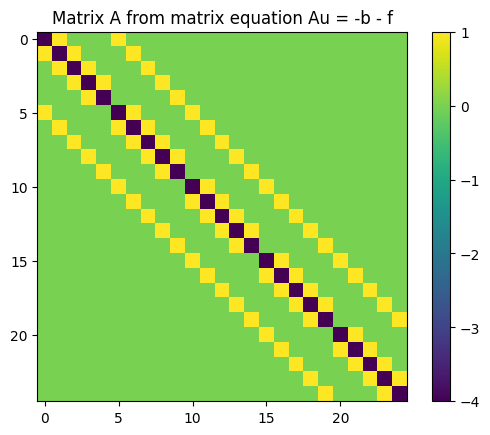

In [ ]:
#Visualizing matrix A to check if it has been properly constructed
A, y = heat_equation_system(5, 0, np.zeros((5,5)), 100)
plt.imshow(A.toarray())
plt.colorbar()
plt.title('Matrix A from matrix equation Au = -b - f')

Text(0.5, 1.0, 'Vector -b - f from matrix equation Au = -b - f')

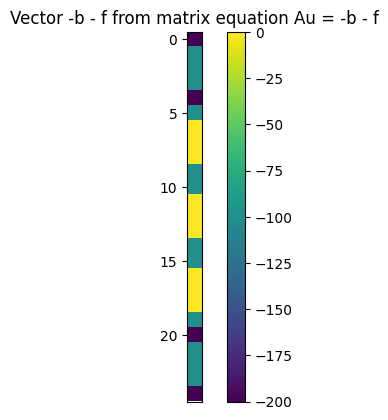

In [ ]:
#Checking if target vector has been constructed properly
plt.imshow(y)
plt.colorbar()
plt.xticks([])
plt.title('Vector -b - f from matrix equation Au = -b - f')

##Diagonal Extraction & Display


In [ ]:
import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt

# parameters
n = 10
border_temp = 100
k = 0

# build A
X, Y = np.meshgrid(np.linspace(-np.floor(n/2), np.floor(n/2), n),
                   np.linspace(-np.floor(n/2), np.floor(n/2), n))
f_demo = np.zeros((n,n))
A, y = heat_equation_system(n, k, f_demo, border_temp)

# extract diagonal (sparse format)
D_sparse = sparse.diags(A.diagonal())

# clean display of diagonal
diag_values = A.diagonal()
print("Diagonal entries of A:\n")
print(diag_values)


Diagonal entries of A:

[-4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4.
 -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4.
 -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4.
 -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4.
 -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4. -4.
 -4. -4. -4. -4. -4. -4. -4. -4. -4. -4.]


Now that we have the code for generating our system of equations, we will discuss and implement the Jacobi and Gauss-Seidel iterative methods.

## The Jacobi Method
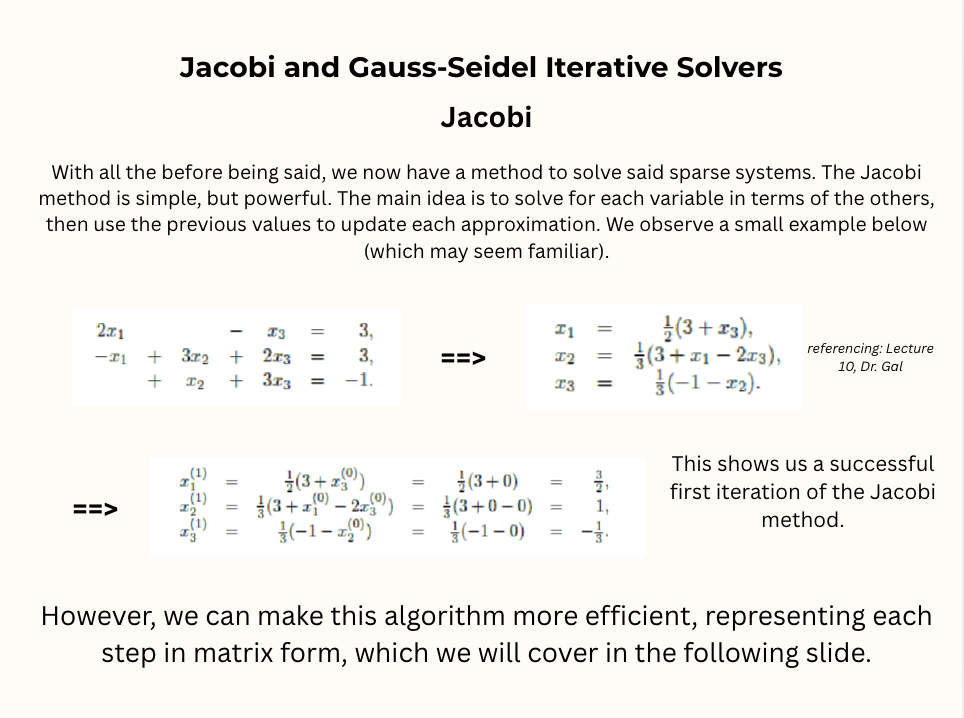

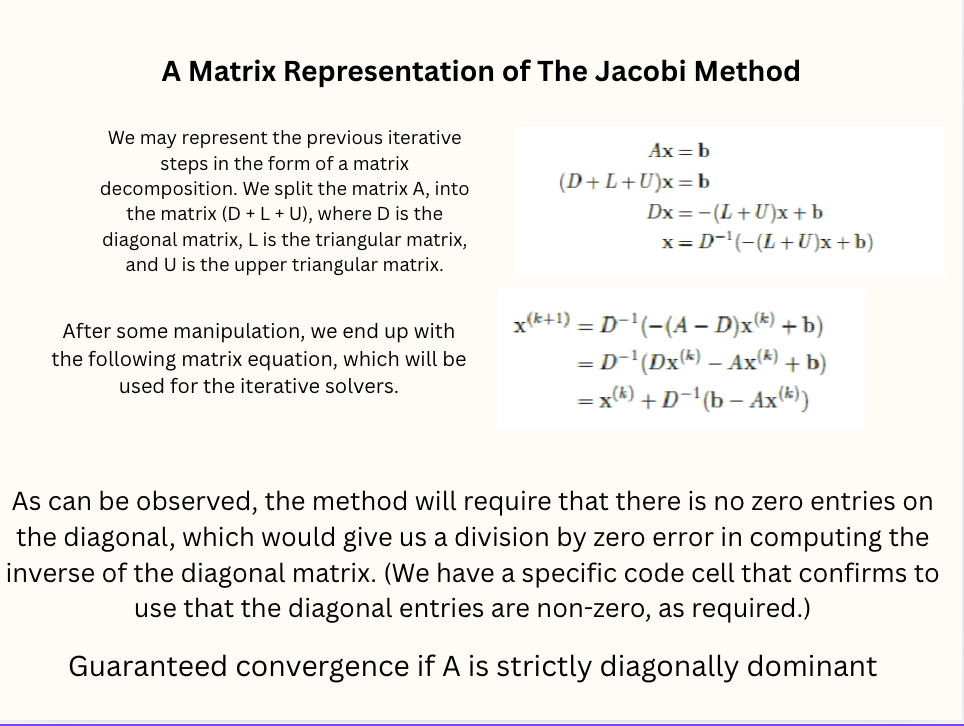


In [ ]:
import numpy as np
from scipy import sparse
import time


def jacobi(A, b, maxiter=100, tol=1e-8):
    """
    Solves the linear system A x = b using the Jacobi iterative method.
    Tracks residuals and runtime for convergence analysis.

    parameters:
        A (array-like): coefficient matrix of size (n, n)
        b (array-like): rhs vector of size (n,)
        maxiter (int): maximum number of iterations. Defaults to 100.
        tol (float): convergence tolerance. Defaults to 1e-8.

    returns:
        dict: Contains keys:
            'x' (ndarray): approximate solution vector.
            'residuals' (ndarray): infinity norm of residual at each iteration.
            'iterations' (int): number of iterations performed.
            'runtime' (float): elapsed time in seconds.
    """
    # abstract arrays, float format
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)

    # initial guess

    x = np.zeros(n)


    # taking diagonal from A
    D = np.diag(np.diag(A))

    # singularity check
    if np.linalg.det(D) == 0:
        raise ValueError("Matrix has zero diagonal entries. Jacobi method requires all diagonal elements to be nonzero for invertibility.")

    # D^-1 (can't use native function, using reciprocal property)
    D_inv = np.diag(1 / np.diag(D))

    # tracking setup
    residuals = []
    start = time.time()

    # iterator
    for k in range(maxiter):
        # storing variable for cleaner code and convergence test (residual)
        r = b - A @ x

        # compute residual norm and store
        res = np.linalg.norm(r, ord=np.inf)
        residuals.append(res)

        # convergence test using infinity norm
        if res < tol:
            break

        # updating formula
        x = x + D_inv @ r

    # compute runtime and iteration count
    runtime = time.time() - start
    iterations = k + 1

    return {"x": x, "residuals": np.array(residuals), "iterations": iterations, "runtime": runtime}


## The Gauss-Seidel Method





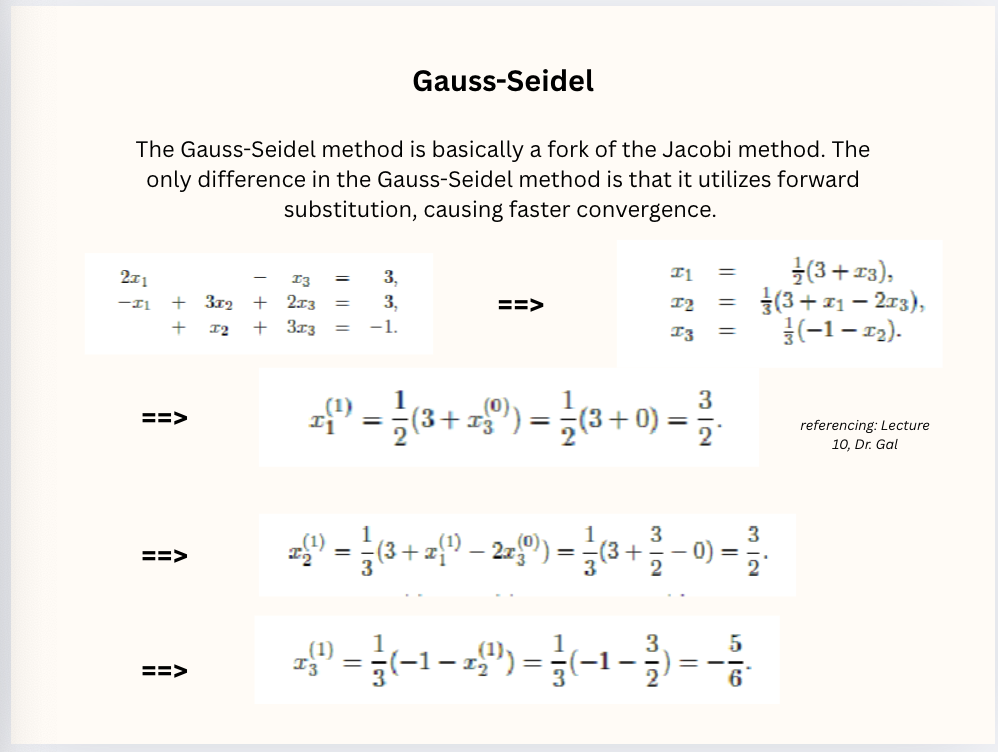

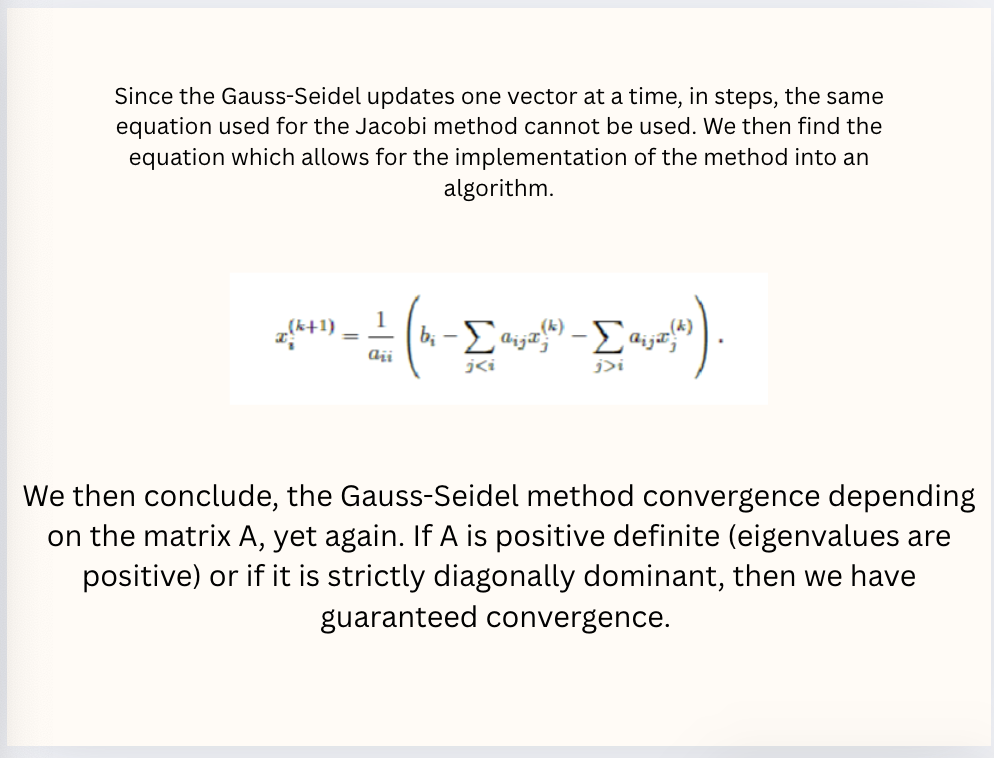

In [ ]:
from matplotlib.backend_bases import NonGuiException
import numpy as np
import time

def GaussSeidel(A, b, maxiter=100, tol=1e-8):
    """
    Solves the linear system A x = b using the Gauss-Seidel iterative method.
    Tracks residuals and runtime for convergence analysis.

    parameters:
        A (array-like): coefficient matrix of size (n, n)
        b (array-like): rhs vector of size (n,)
        maxiter (int): maximum number of iterations. Defaults to 100.
        tol (float): convergence tolerance. Defaults to 1e-8.


    returns:
        dict: Contains keys:
            'x' (ndarray): approximate solution vector.
            'residuals' (ndarray): infinity norm of residual at each iteration.
            'iterations' (int): number of iterations performed.
            'runtime' (float): elapsed time in seconds.
    """
    A = A.astype(float)
    b = b.astype(float)
    n = len(b)

    # initial guess
    x = np.zeros(n)



    # tracking setup
    residuals = []
    start = time.time()

    for k in range(maxiter):

        # storing previous iteration as a copy
        x_old = np.copy(x)

        # sweeping through entries (using forward substitution)
        for i in range(n):
            # computing a_i^T x^(k) without the i-th component
            s1 = np.dot(A[i, :i], x[:i])  # j
            s2 = np.dot(A[i, i+1:], x_old[i+1:])  # j

            # update
            x[i] = (b[i] - s1 - s2) / A[i, i]

        # compute residual norm and store
        r = b - A @ x
        res = np.linalg.norm(r, ord=np.inf)
        residuals.append(res)

        # convergence test
        if res < tol:
            break

    # compute runtime and iteration count
    runtime = time.time() - start
    iterations = k + 1

    return {"x": x, "residuals": np.array(residuals), "iterations": iterations, "runtime": runtime}





## Our Experimental Setup

We model a square metal plate with the following configuration:

Boundary Conditions:



*   All four edges of the plate are held at a constant temperature of 100°C
*   This is known as a Dirichlet boundary condition
*   Physically, this could represent the plate being in contact with a heat reservoir (like boiling water) on all sides

Interior Grid:

*   We discretize the interior into a 25 × 25 grid of points
*   The temperature at each interior point is unknown and must be solved for
*   Grid points are assumed to be unit distance apart for simplicity


## The Four Source Functions:

1.   $$f₁(x,y) = 0$$ No internal heat source. This reduces to the Laplace equation (when k=0), and the steady-state solution depends only on the boundary conditions. We expect a uniform temperature of 100°C throughout the plate.

2.   $$f₂(x,y) = δ(x,y) $$A point heat source at the center of the plate. This models a localized heating element, like a soldering iron tip touching the center. We expect to see elevated temperatures radiating outward from the center.
3.   $$f₃(x,y) = ½b·sin(x) $$ A sinusoidal heat source that varies with the x-coordinate. This creates alternating bands of heat generation and absorption, similar to a heating element with periodic hot and cold sections.
4.   $$f₄(x,y) = ½b·cos(√(x²+y²))$$ A radial cosine source depending on distance from the center. This creates concentric rings of alternating heat generation and absorption.

### Physical Relevance



1.   Electronic Cooling: The point source model resembles a CPU or chip generating heat at a localized point. Our results show how heat spreads from such sources and how cooling (k < 0) can manage temperatures.
2.   Industrial Heating: The sinusoidal source could model heating elements with periodic temperature variations, useful for understanding heat distribution in industrial processes.
3.   Material Processing: Understanding how different source configurations and cooling rates affect temperature distribution is crucial for processes like heat treatment, welding, and semiconductor manufacturing.
4.   Building Thermal Management: The boundary-driven heat flow with environmental cooling (k < 0) models how buildings exchange heat with the environment.


## The Three Values of k

For each source function, we test three scenarios:

| k Value | Physical Meaning | Expected Effect |
|---------|------------------|-----------------|
| k = 0 | Pure diffusion (Laplace equation) | Temperature determined by boundaries and sources only |
| k = 0.01 | Mild exothermic reaction | Temperatures elevated, especially in interior |
| k = -1 | Strong environmental cooling | Temperatures pulled toward 0°C, especially in interior |

This gives us **12 total experiments** (4 sources × 3 values of k).

## Numerical Experiments


EXPERIMENT IS ZERO_SOURCE

testing k = 0 (zero (Laplace equation))



/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)


jacobi: 2730 iterations
jacobi: 0.869034 seconds
jacobi final residual: 0.0000000100
jacobi: converged

gauss-seidel: 1366 iterations
gauss-seidel: 4.094763 seconds
gauss-seidel final residual: 0.0000000100
gauss-seidel: converged

testing k = 0.01 (positive (exothermic reaction - heat generation))

jacobi: 4150 iterations
jacobi: 1.211123 seconds
jacobi final residual: 0.0000000099
jacobi: converged

gauss-seidel: 2076 iterations
gauss-seidel: 7.271363 seconds
gauss-seidel final residual: 0.0000000099
gauss-seidel: converged

testing k = -1 (negative (cooling to environment - heat loss))

jacobi: 87 iterations
jacobi: 0.030642 seconds
jacobi final residual: 0.0000000089
jacobi: converged

gauss-seidel: 50 iterations
gauss-seidel: 0.188476 seconds
gauss-seidel final residual: 0.0000000066
gauss-seidel: converged


EXPERIMENT IS POINT_SOURCE

testing k = 0 (zero (Laplace equation))

jacobi: 2762 iterations
jacobi: 0.833037 seconds
jacobi final residual: 0.0000000099
jacobi: converged

g

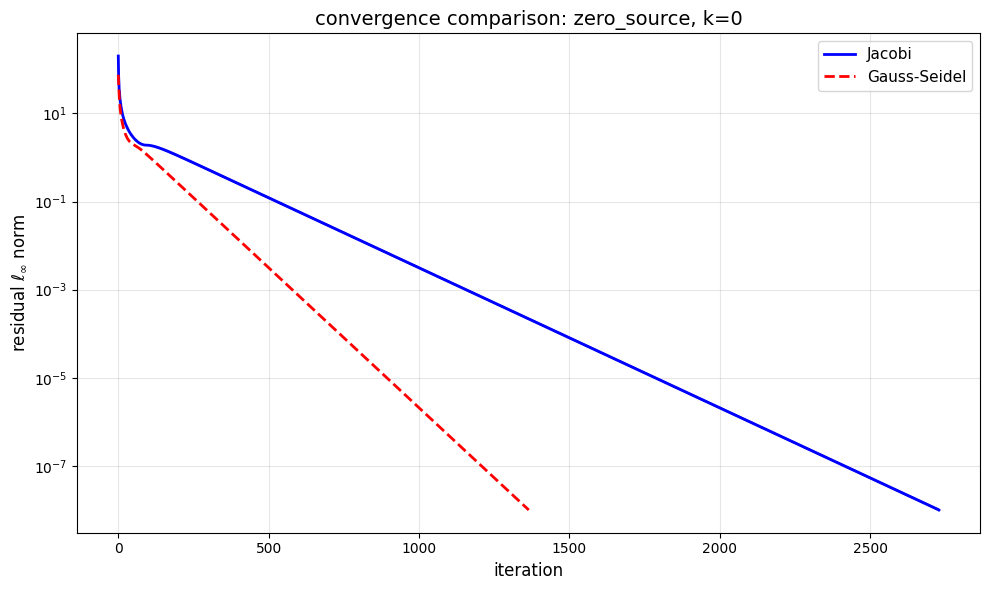

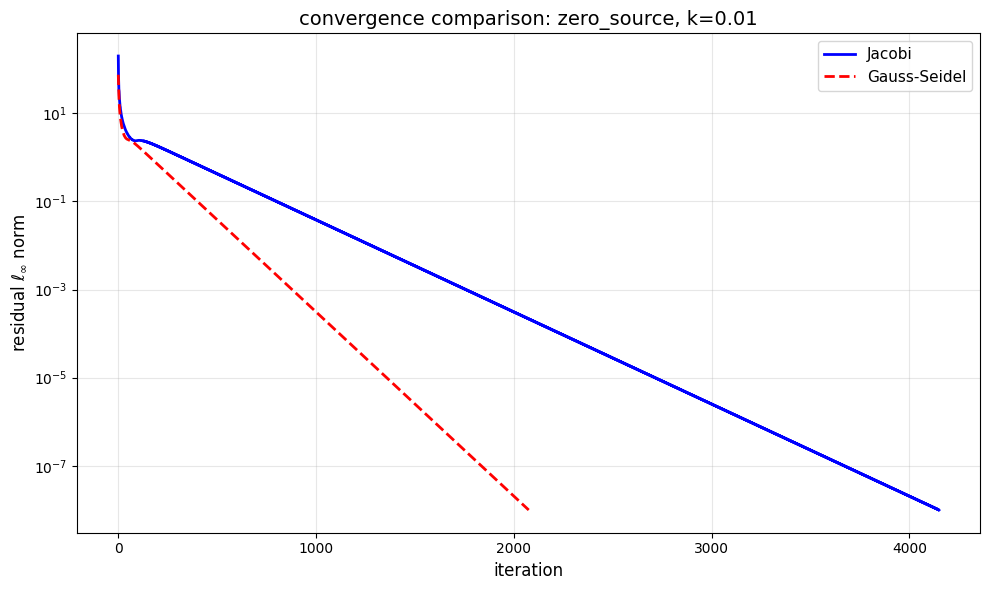

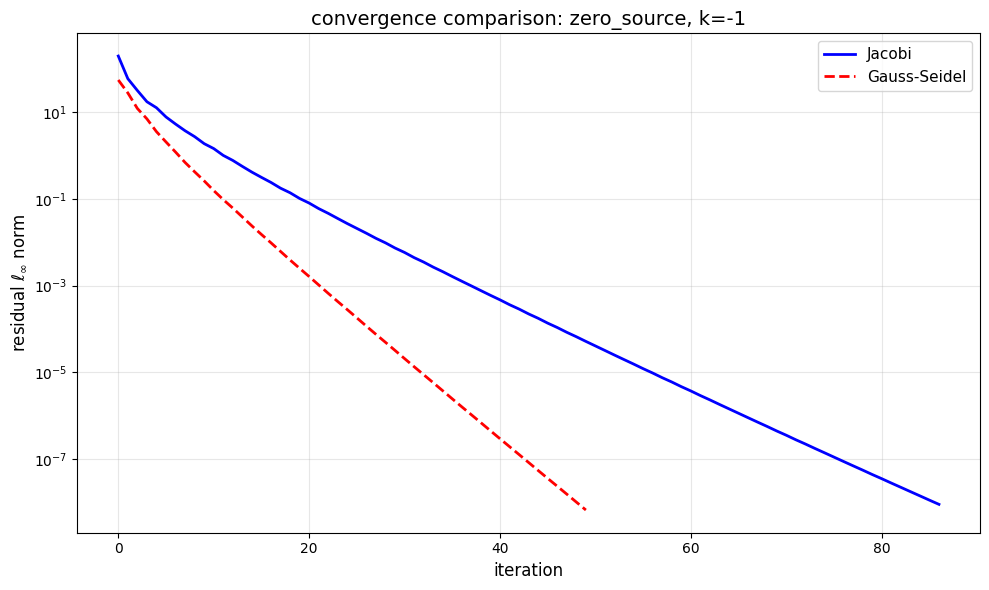

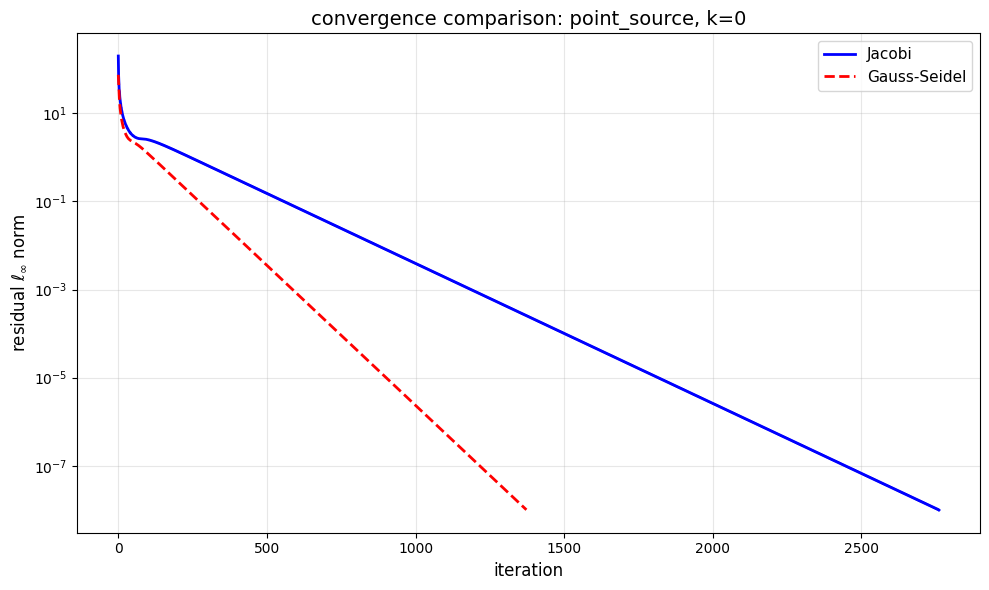

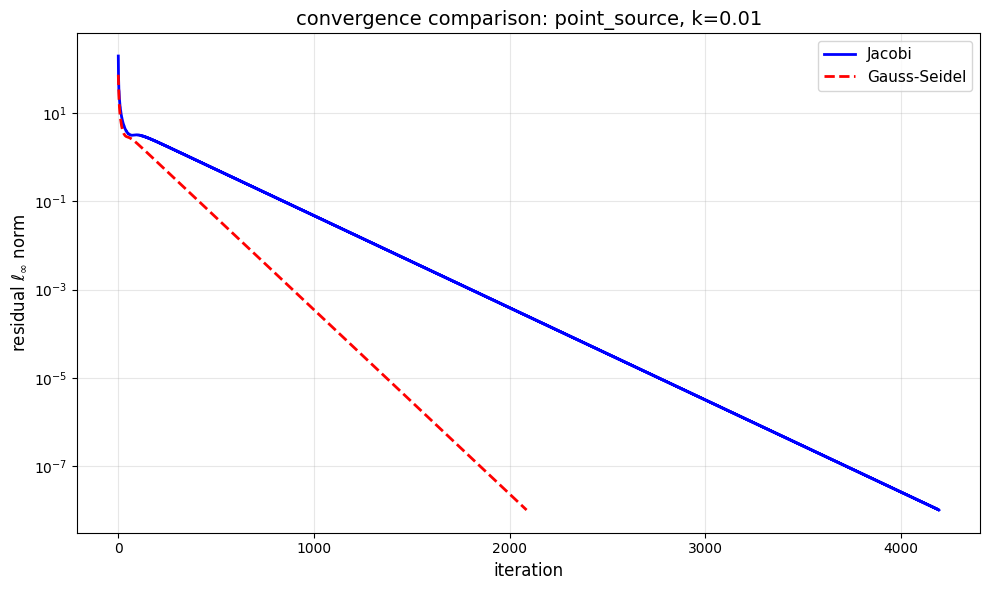

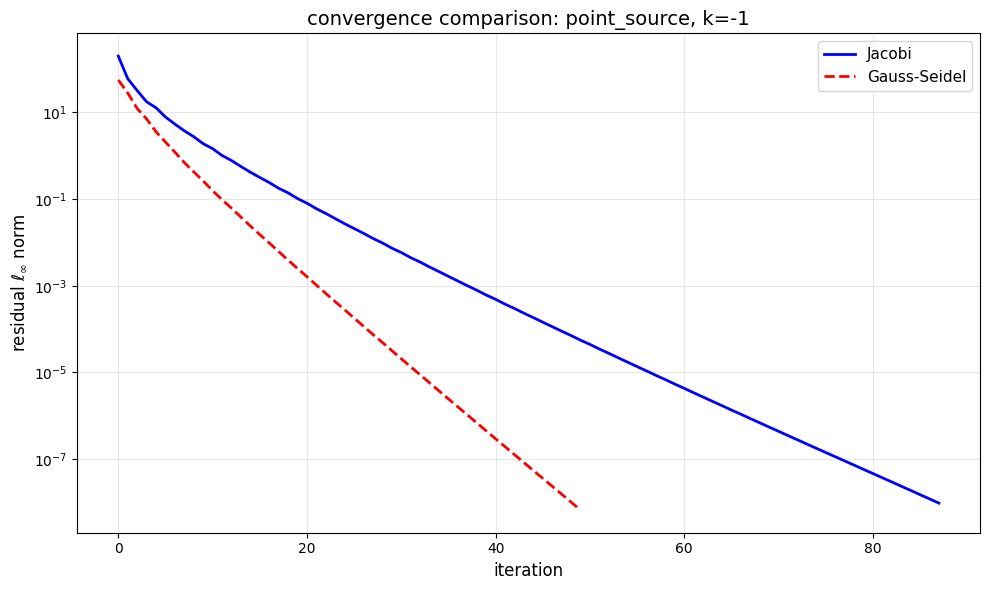

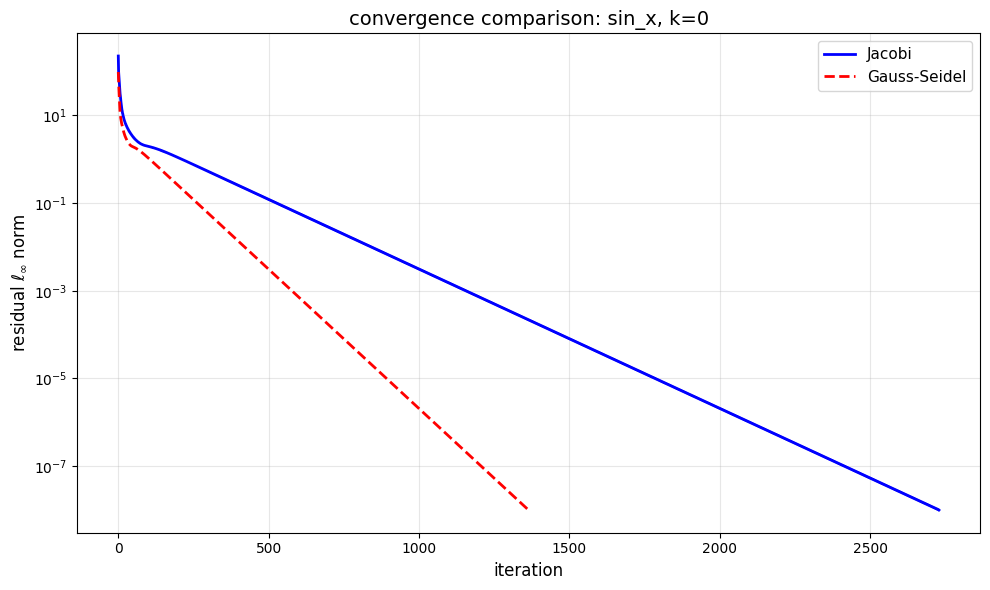

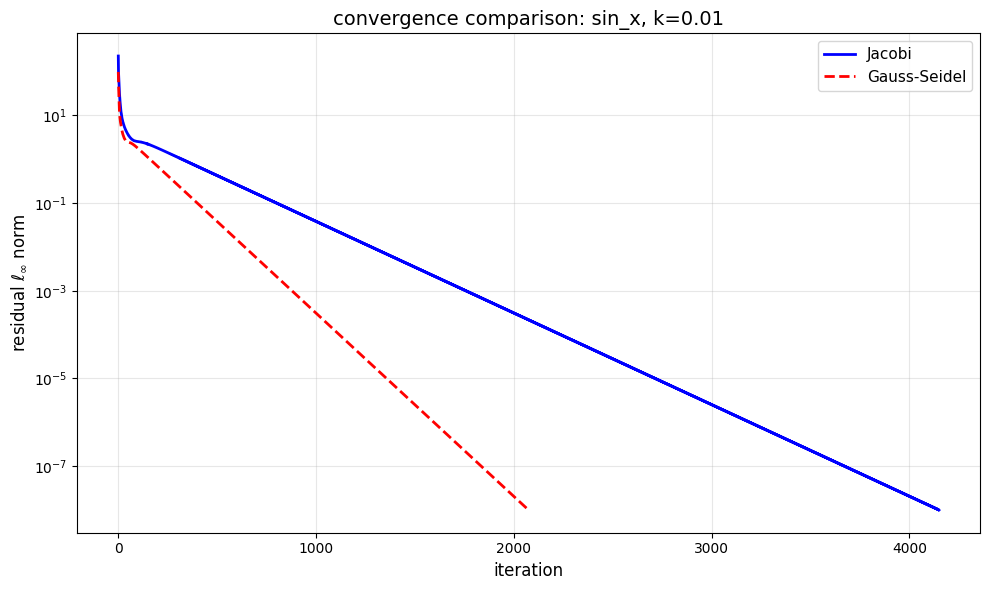

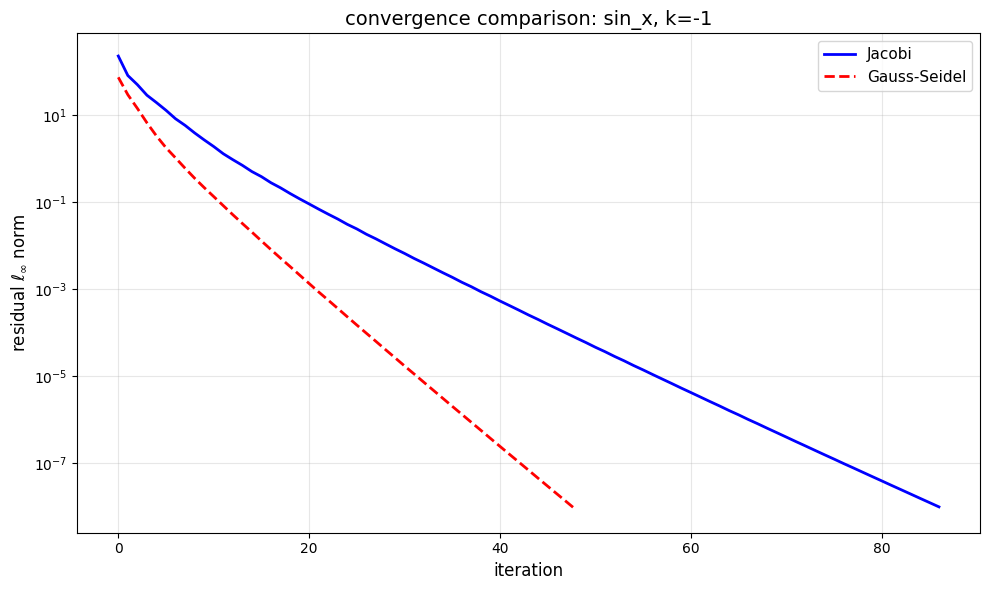

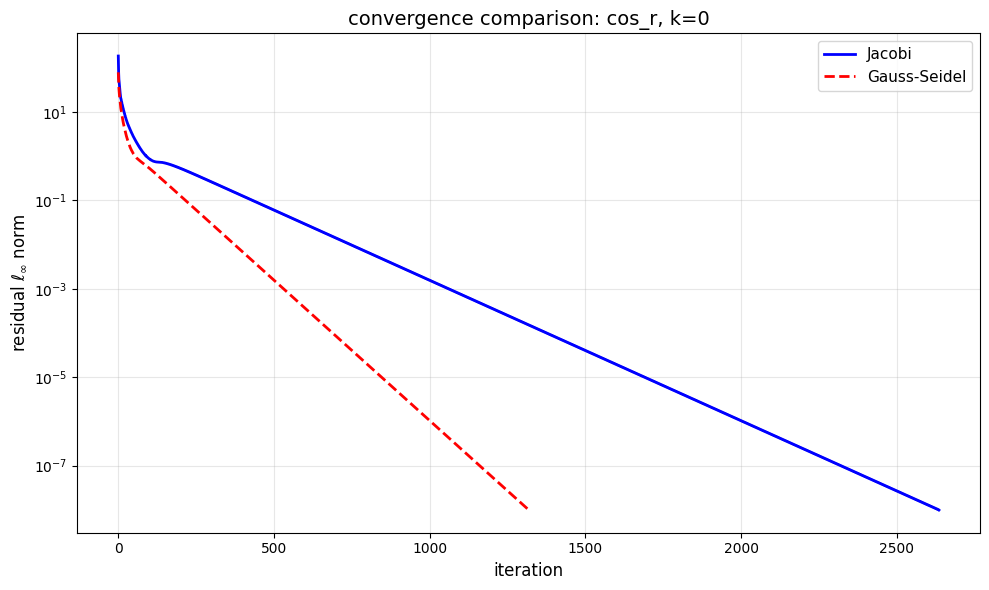

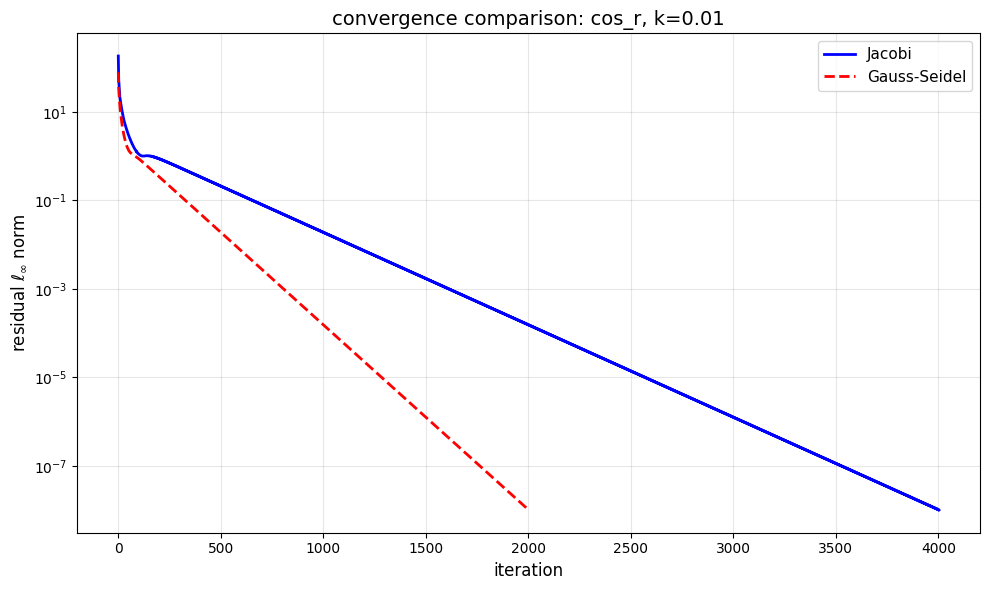

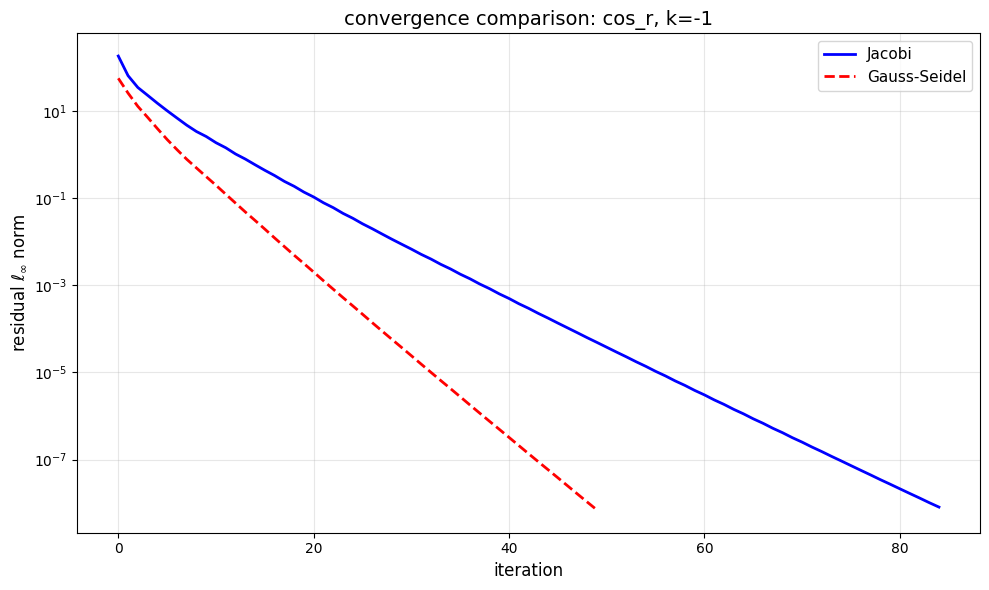

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import zipfile
from google.colab import files


# parameters
border_temp = 100
n = 25
tol = 1e-8
maxiter = 10000


# grid for source functions
sequence = np.linspace(-np.floor(n/2), np.floor(n/2), n)
X, Y = np.meshgrid(sequence, sequence)


# defining the four source/sink functions
def zero_source(X, Y, border_temp):
    # no internal heat sources - pure boundary problem (Laplace equation when k=0)
    return np.zeros((n, n))


def point_source(X, Y, border_temp):
    # point heat source at center (heat generation)
    f = np.zeros((n, n))
    f[int(np.floor(n/2)), int(np.floor(n/2))] = border_temp
    return f


def sin_x_source(X, Y, border_temp):
    # sin(x) distributed heat source
    return 0.5 * border_temp * np.sin(X)


def cos_r_source(X, Y, border_temp):
    # cos(distance from origin) distributed heat source
    return 0.5 * border_temp * np.cos(np.sqrt(X**2 + Y**2))


# helper function to check convergence
def check_convergence(result, tol):
    return "converged" if result['residuals'][-1] < tol else "did not converge"


# defining experiments: (name, source_function, k_zero, k_positive, k_negative)
experiments = [
    ("zero_source", zero_source(X, Y, border_temp), 0, .01, -1),
    ("point_source", point_source(X, Y, border_temp), 0, .01, -1),
    ("sin_x", sin_x_source(X, Y, border_temp), 0, .01, -1),
    ("cos_r", cos_r_source(X, Y, border_temp), 0, .01, -1)
]


# storage for all the results
all_results = {}
saved_files = []  # store filenames for zip creation


# running all experiments
for exp_name, f_source, k_zero, k_pos, k_neg in experiments:

    print(f"\nEXPERIMENT IS {exp_name.upper()}\n")

    # testing k=0, positive k, and negative k
    for k in [k_zero, k_pos, k_neg]:

        if k == 0:
            k_sign = "zero (Laplace equation)"
        elif k > 0:
            k_sign = "positive (exothermic reaction - heat generation)"
        else:
            k_sign = "negative (cooling to environment - heat loss)"

        print(f"testing k = {k} ({k_sign})\n")

        # building the heat equation system
        A, y = heat_equation_system(n, k, f_source, border_temp)

        # convert once and reuse
        A_array = A.toarray()
        y_array = y.flatten()

        # running jacobi
        result_jacobi = jacobi(A_array, y_array, maxiter=maxiter, tol=tol)

        # running gauss-seidel
        result_gs = GaussSeidel(A_array, y_array, maxiter=maxiter, tol=tol)

        # storing results
        key = f"{exp_name}_k{k}"
        all_results[key] = {
            "jacobi": result_jacobi,
            "gauss_seidel": result_gs,
            "k": k,
            "source_name": exp_name
        }

        # print results - jacobi
        jac_status = check_convergence(result_jacobi, tol)
        print(f"jacobi: {result_jacobi['iterations']} iterations")
        print(f"jacobi: {result_jacobi['runtime']:.6f} seconds")
        print(f"jacobi final residual: {result_jacobi['residuals'][-1]:.10f}")
        print(f"jacobi: {jac_status}\n")

        # print results - gauss-seidel
        gs_status = check_convergence(result_gs, tol)
        print(f"gauss-seidel: {result_gs['iterations']} iterations")
        print(f"gauss-seidel: {result_gs['runtime']:.6f} seconds")
        print(f"gauss-seidel final residual: {result_gs['residuals'][-1]:.10f}")
        print(f"gauss-seidel: {gs_status}\n")

        # saving solution arrays
        sol_jacobi = result_jacobi["x"].reshape(n, n)
        sol_gs = result_gs["x"].reshape(n, n)

        jacobi_file = f"{exp_name}_k{k}_jacobi.npy"
        gauss_file = f"{exp_name}_k{k}_gauss_seidel.npy"

        np.save(jacobi_file, sol_jacobi)
        np.save(gauss_file, sol_gs)

        # store filenames for zip creation
        saved_files.append(jacobi_file)
        saved_files.append(gauss_file)


print("\nPLOTTING\n")


# creating the convergence plots
fig_count = 1
for exp_name, _, k_zero, k_pos, k_neg in experiments:
    for k in [k_zero, k_pos, k_neg]:

        key = f"{exp_name}_k{k}"

        jac_res = all_results[key]["jacobi"]["residuals"]
        gs_res = all_results[key]["gauss_seidel"]["residuals"]

        plt.figure(figsize=(10, 6))
        plt.semilogy(range(len(jac_res)), jac_res, 'b-', label='Jacobi', linewidth=2)
        plt.semilogy(range(len(gs_res)), gs_res, 'r--', label='Gauss-Seidel', linewidth=2)

        plt.xlabel('iteration', fontsize=12)
        plt.ylabel('residual $\\ell_\\infty$ norm', fontsize=12)
        plt.title(f'convergence comparison: {exp_name}, k={k}', fontsize=14)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plt.show()

        fig_count += 1


# creating zip file with all results
with zipfile.ZipFile('heat_equation_results.zip', 'w') as zipf:
    for filename in saved_files:
        zipf.write(filename)

# downloading the zip file
files.download('heat_equation_results.zip')




In [ ]:
print ()

## HEATMAP VISUALIZATIONS WITH PADDING AND INTERPOLATION

In [ ]:

def add_boundary_padding(solution_matrix, border_temp):
    """
    Add boundary padding to the solution matrix.
    The boundary represents the fixed temperature at the edges of the plate.
    """
    padded = np.pad(solution_matrix,
                    pad_width=1,
                    mode='constant',
                    constant_values=border_temp)
    return padded


def smooth_interpolation(matrix, scale_factor=4):
    """
    Apply smooth interpolation to the matrix for better visualization.
    Uses scipy's zoom function for smooth transitions (cubic interpolation).
    """
    return zoom(matrix, scale_factor, order=3)


def get_global_temp_range(all_results, n, border_temp):
    """
    Calculate the global min and max temperature across ALL experiments.
    This ensures consistent color mapping across all visualizations.
    """
    all_temps = []
    for key, data in all_results.items():
        sol = data["jacobi"]["x"].reshape(n, n)
        padded = add_boundary_padding(sol, border_temp)
        all_temps.extend(padded.flatten())

        sol_gs = data["gauss_seidel"]["x"].reshape(n, n)
        padded_gs = add_boundary_padding(sol_gs, border_temp)
        all_temps.extend(padded_gs.flatten())
    return np.min(all_temps), np.max(all_temps)

In [ ]:
# Get global temperature range for consistent coloring

vmin, vmax = get_global_temp_range(all_results, n, border_temp)
print(f"Global temperature range across all experiments: {vmin:.2f}°C to {vmax:.2f}°C")
print("Using this range for consistent color mapping in all heatmaps.\n")

Global temperature range across all experiments: -53.75°C to 257.54°C
Using this range for consistent color mapping in all heatmaps.



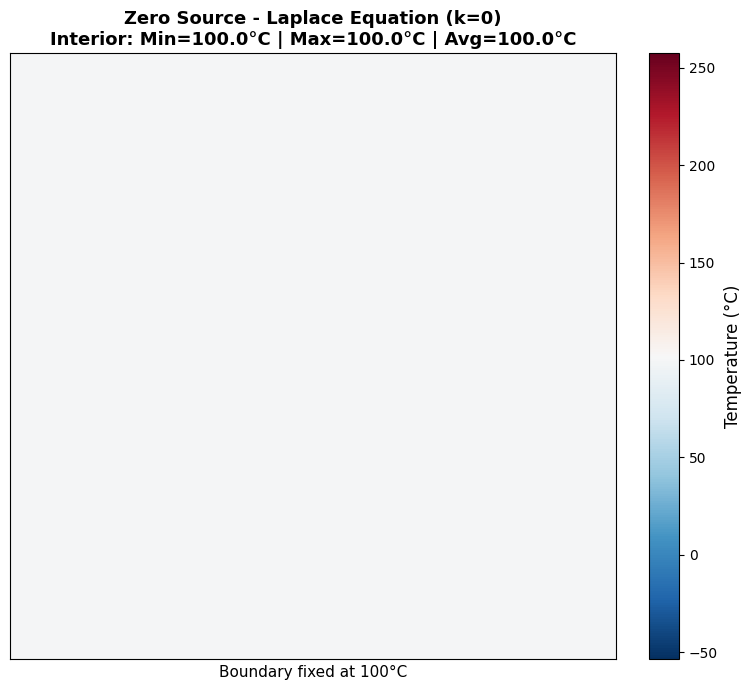

  ✓ Generated heatmap for zero_source_k0


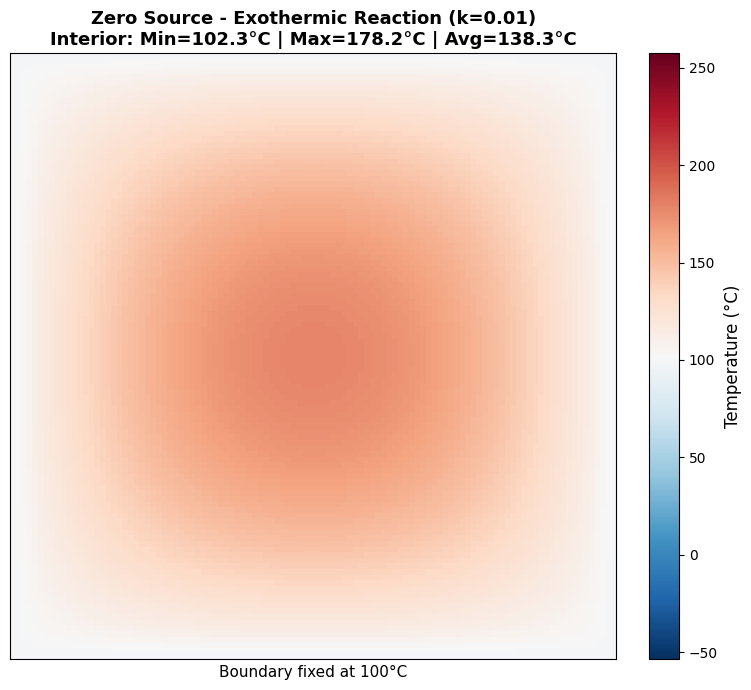

  ✓ Generated heatmap for zero_source_k0.01


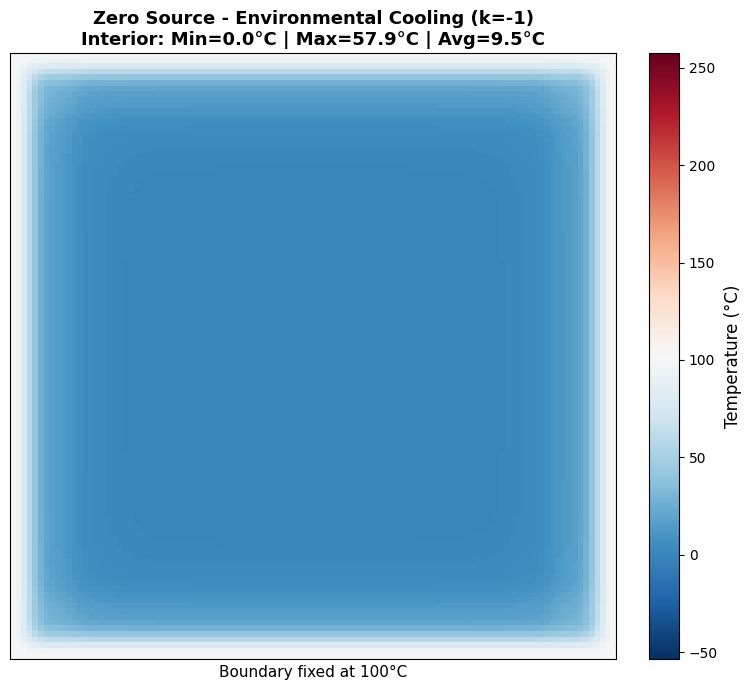

  ✓ Generated heatmap for zero_source_k-1


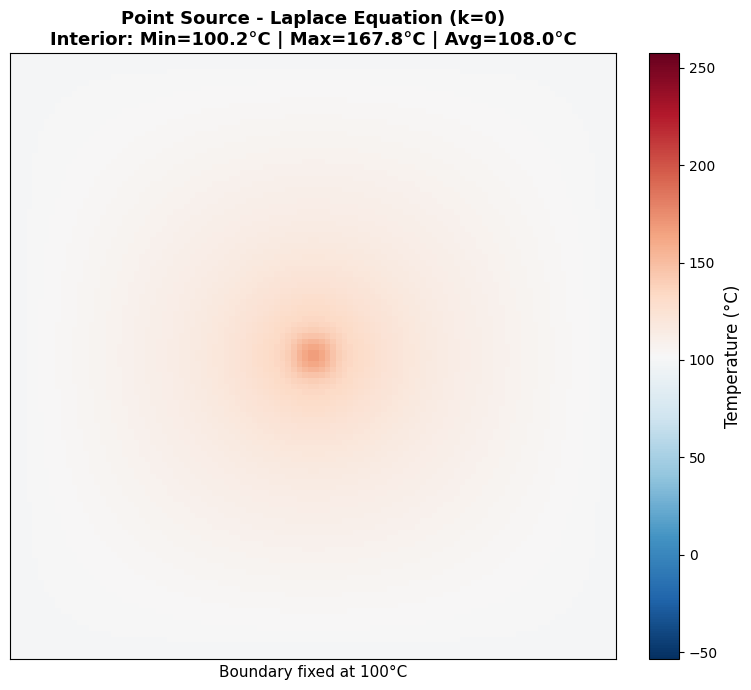

  ✓ Generated heatmap for point_source_k0


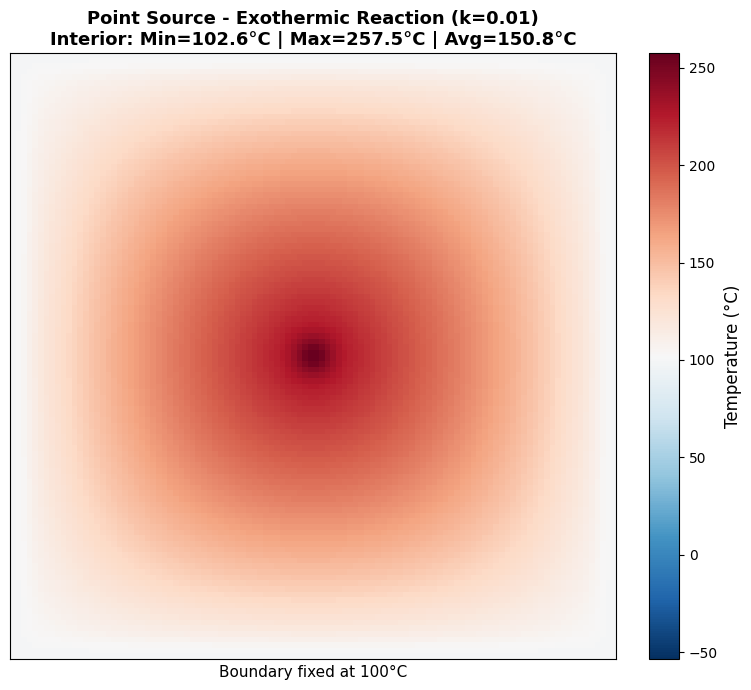

  ✓ Generated heatmap for point_source_k0.01


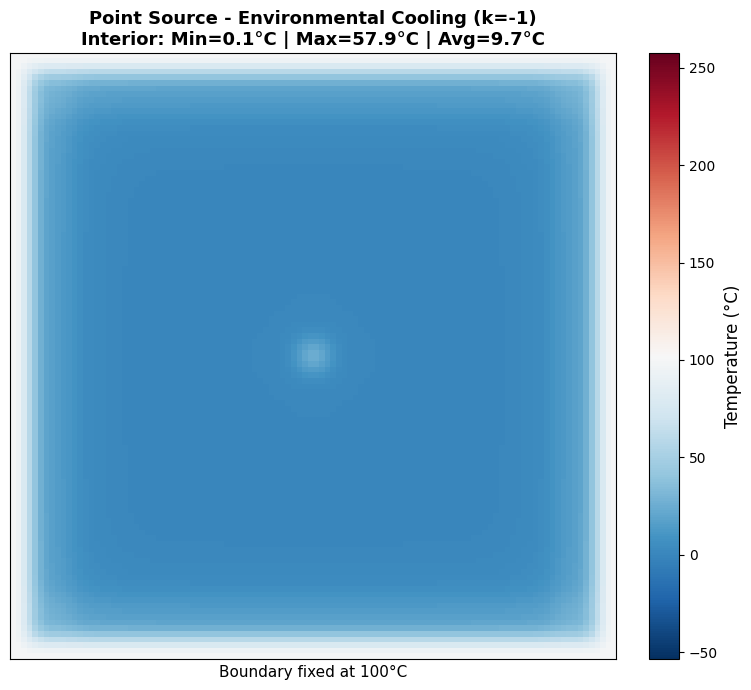

  ✓ Generated heatmap for point_source_k-1


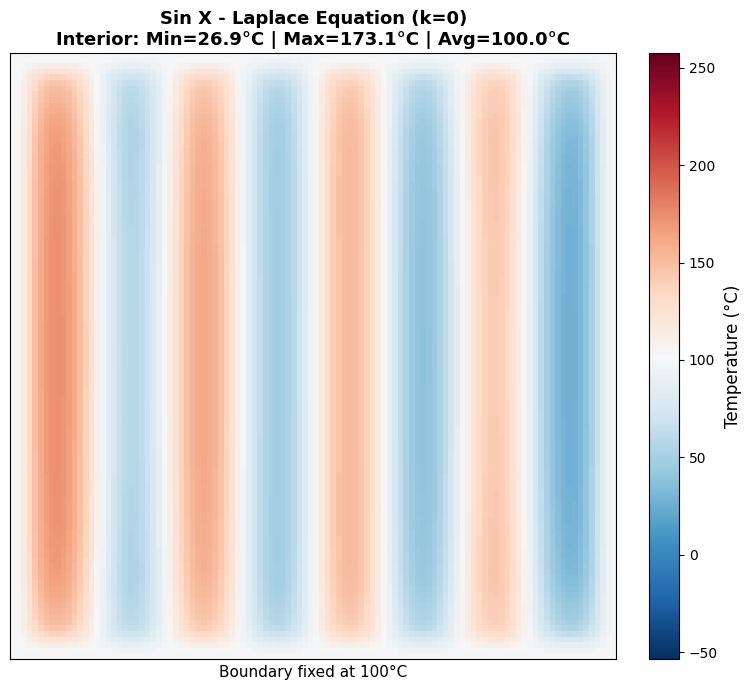

  ✓ Generated heatmap for sin_x_k0


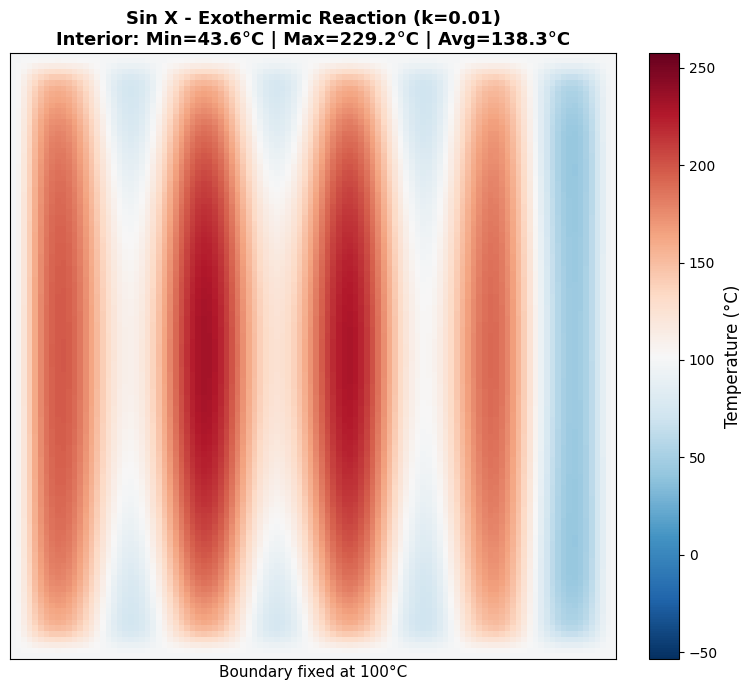

  ✓ Generated heatmap for sin_x_k0.01


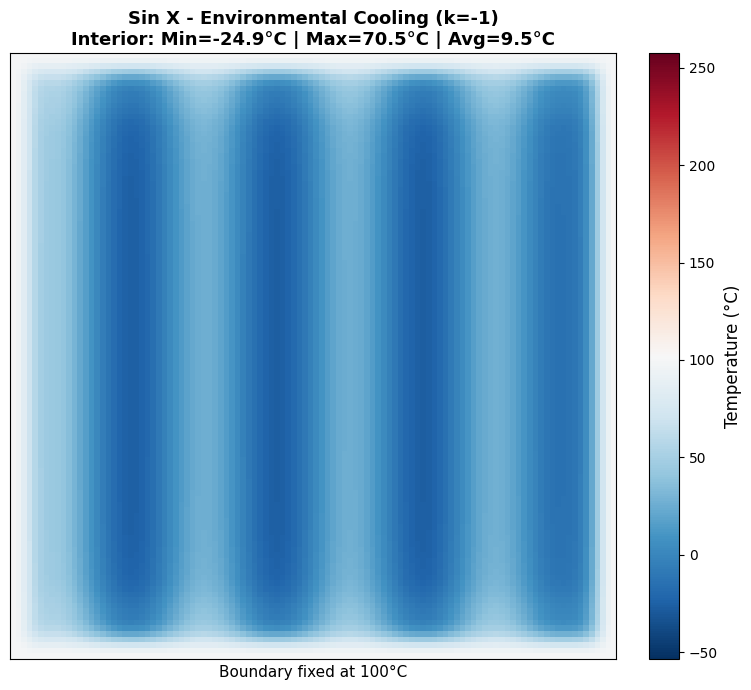

  ✓ Generated heatmap for sin_x_k-1


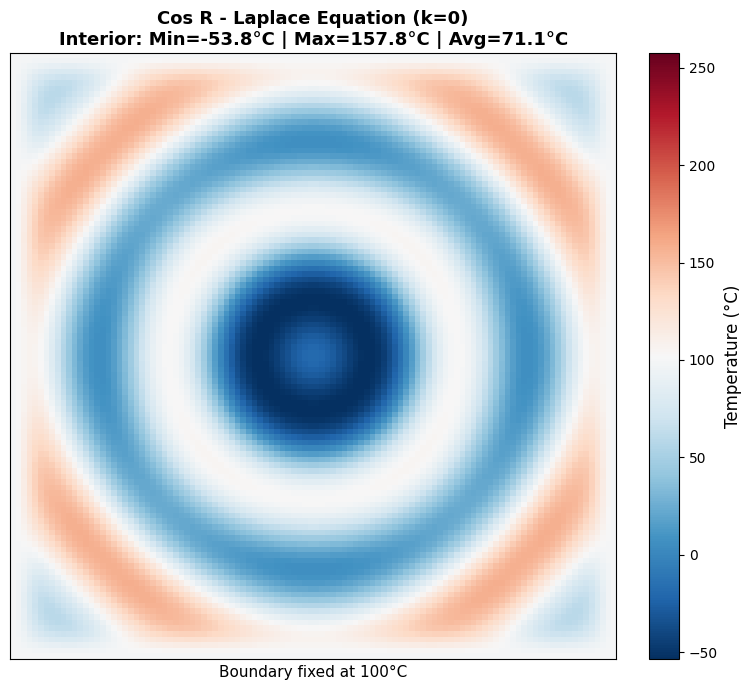

  ✓ Generated heatmap for cos_r_k0


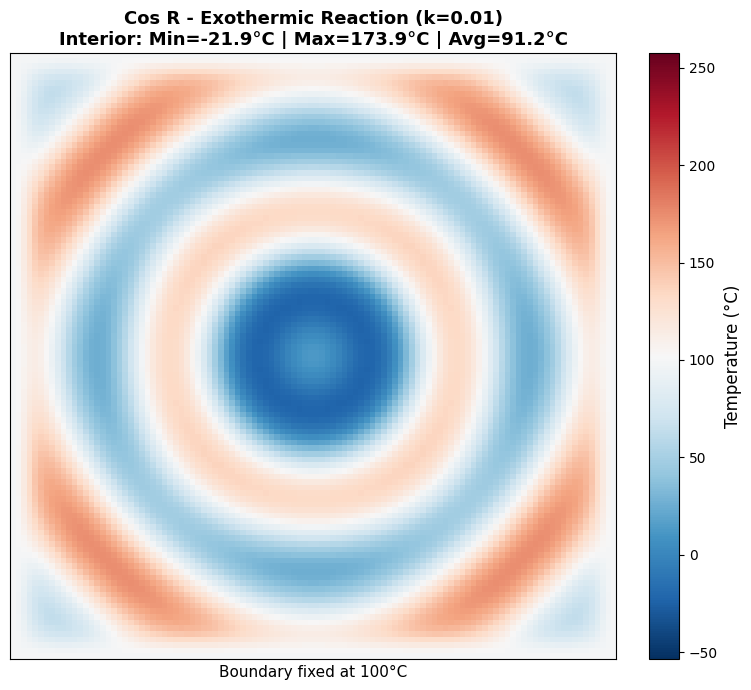

  ✓ Generated heatmap for cos_r_k0.01


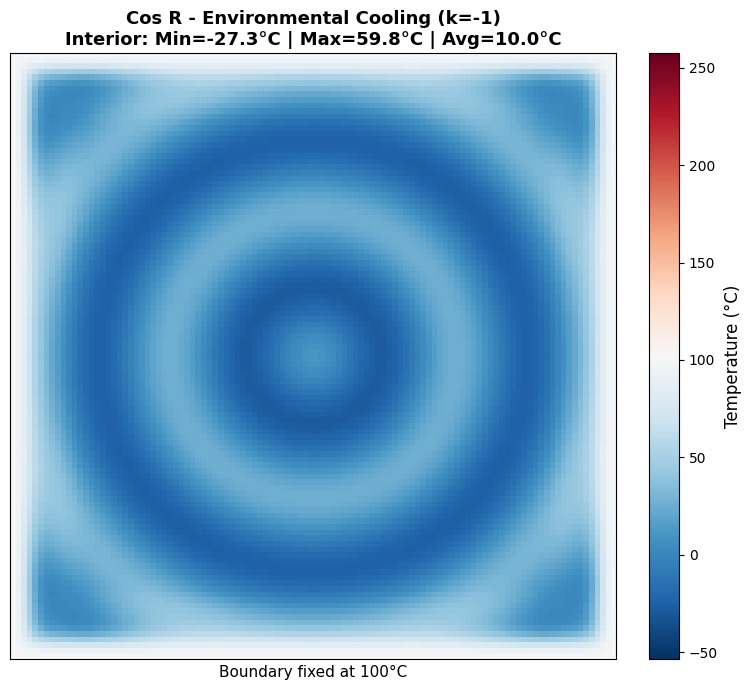

  ✓ Generated heatmap for cos_r_k-1



In [ ]:
# Create individual heatmaps for each experiment

from scipy.ndimage import zoom

for key, data in all_results.items():
    # Reshape solution to n x n grid
    sol = data["jacobi"]["x"].reshape(n, n)

    # Add boundary padding
    padded = add_boundary_padding(sol, border_temp)

    # Apply smooth interpolation
    smoothed = smooth_interpolation(padded, scale_factor=4)

    # Calculate temperature statistics
    temp_min = np.min(sol)
    temp_max = np.max(sol)
    temp_avg = np.mean(sol)

    # Create the figure
    fig, ax = plt.subplots(figsize=(9, 7))

    # Plot with consistent color scale
    im = ax.imshow(smoothed, cmap='RdBu_r', vmin=vmin, vmax=vmax, origin='upper')

    # Add colorbar with temperature label
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Temperature (°C)', fontsize=12)

    # Create descriptive title
    k_val = data["k"]
    source = data["source_name"].replace("_", " ").title()

    if k_val == 0:
        k_desc = "Laplace Equation (k=0)"
    elif k_val > 0:
        k_desc = f"Exothermic Reaction (k={k_val})"
    else:
        k_desc = f"Environmental Cooling (k={k_val})"

    # Title with statistics
    title = f'{source} - {k_desc}'
    stats = f'Interior: Min={temp_min:.1f}°C | Max={temp_max:.1f}°C | Avg={temp_avg:.1f}°C'
    ax.set_title(f'{title}\n{stats}', fontsize=13, fontweight='bold')

    # Clean up axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(f'Boundary fixed at {border_temp}°C', fontsize=11)

    plt.tight_layout()
    plt.savefig(f'heatmap_{key}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  ✓ Generated heatmap for {key}")


print ()




In [ ]:

print ()

## Discussion of Heatmap Visualizations

### Insights from the Temperature Distributions
After solving the heat equation using both the Jacobi and Gauss-Seidel iterative methods, we visualized the steady-state temperature distributions as heatmaps. The visualizations reveal important physical insights about heat diffusion processes.

### How Heat Flows from the Boundaries
In all our experiments, heat flows from the boundaries (fixed at 100°C) into the interior of the plate. The direction and magnitude of heat flow depend on the source function and the value of k:
*   For f₁ = 0 with k = 0: With no internal sources and pure diffusion, heat from the 100°C boundaries diffuses uniformly inward. The steady-state solution is a constant 100°C everywhere — the plate reaches thermal equilibrium with the boundaries.
*   For f₁ = 0 with k = -1 (cooling): The plate loses heat to the environment. Heat flows from the hot boundaries toward the interior, but the interior also loses heat to the surroundings. The result is a temperature gradient with the center significantly cooler (around 10°C average) than the boundaries.
*   For f₁ = 0 with k = 0.01 (exothermic): Internal heat generation raises the interior temperature above the boundary temperature. Heat actually flows outward from the center toward the boundaries, which act as heat sinks.

### Steady-State Distribution Patterns
The steady-state distributions reveal characteristic patterns for each source function:


Zero Source (f₁ = 0):

*   k = 0: Uniform temperature (100°C everywhere)
*   k = 0.01: Dome-shaped distribution, hottest in center (~138°C average)
*   k = -1: Bowl-shaped distribution, coolest in center (~10°C average)

Point Source (f₂ = δ):

*   Creates a distinct "hot spot" at the center of the plate
*   Temperature radiates outward from the center, decreasing toward the boundaries
*   With k = 0.01, the maximum temperature reaches ~258°C at the center
*   With k = -1, the hot spot is suppressed, reaching only ~58°C

Sinusoidal Source (f₃ = sin(x)):

*   Creates vertical bands of alternating hot and cold regions
*   The wave pattern is clearly visible in the heatmap
*   Demonstrates how spatially varying heat sources create non-uniform temperature distributions
*   The pattern is more pronounced with k = 0.01 and suppressed with k = -1

Radial Cosine Source (f₄ = cos(r)):

*   Creates concentric ring patterns centered on the origin
*   The center can be hot or cold depending on the phase of the cosine
*   With our parameters, the center is actually a heat sink (negative source), creating a cold spot surrounded by warmer rings

###Key Observations:


1.   The cooling parameter (k = -1) dramatically reduces all temperatures, pulling the average from ~100°C down to ~10°C. This demonstrates the strong effect of environmental heat loss.
2.   The exothermic parameter (k = 0.01) elevates temperatures, with averages increasing by 30-50°C above the boundary temperature in some cases.
3.   Point sources create the most extreme temperature gradients, with maximum temperatures nearly 160°C above the boundary when k = 0.01.
4.   Negative temperatures are possible when heat sinks (negative source values) combine with environmental cooling (k = -1). The cos(r) source with k = -1 produces temperatures as low as -27°C.



In [ ]:
print ()

## RESULTS SUMMARY TABLE

In [ ]:
import pandas as pd

# Create summary data
rows = []
for key, data in all_results.items():
    jac = data["jacobi"]
    gs = data["gauss_seidel"]
    sol = jac["x"].reshape(n, n)

    # Determine convergence status
    jac_conv = "Yes" if jac["residuals"][-1] < tol else "No"
    gs_conv = "Yes" if gs["residuals"][-1] < tol else "No"

    rows.append({
        "Source Function": data["source_name"],
        "k Value": data["k"],
        "Jacobi Iterations": jac["iterations"],
        "Jacobi Runtime (s)": round(jac["runtime"], 4),
        "Jacobi Converged": jac_conv,
        "G-S Iterations": gs["iterations"],
        "G-S Runtime (s)": round(gs["runtime"], 4),
        "G-S Converged": gs_conv,
        "Iteration Speedup": f'{jac["iterations"]/gs["iterations"]:.2f}x',
        "Min Temp (°C)": round(np.min(sol), 1),
        "Max Temp (°C)": round(np.max(sol), 1),
        "Avg Temp (°C)": round(np.mean(sol), 1)
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print("\n" + "="*70)

# Also display as a nicer formatted table if in Colab/Jupyter
try:
    from IPython.display import display, HTML
    display(df)
except:
    pass

Source Function  k Value  Jacobi Iterations  Jacobi Runtime (s) Jacobi Converged  G-S Iterations  G-S Runtime (s) G-S Converged Iteration Speedup  Min Temp (°C)  Max Temp (°C)  Avg Temp (°C)
    zero_source     0.00               2730              0.8690              Yes            1366           4.0948           Yes             2.00x          100.0          100.0          100.0
    zero_source     0.01               4150              1.2111              Yes            2076           7.2714           Yes             2.00x          102.3          178.2          138.3
    zero_source    -1.00                 87              0.0306              Yes              50           0.1885           Yes             1.74x            0.0           57.9            9.5
   point_source     0.00               2762              0.8330              Yes            1374           4.1436           Yes             2.01x          100.2          167.8          108.0
   point_source     0.01               4196  

,Source Function,k Value,Jacobi Iterations,Jacobi Runtime (s),Jacobi Converged,G-S Iterations,G-S Runtime (s),G-S Converged,Iteration Speedup,Min Temp (°C),Max Temp (°C),Avg Temp (°C)
0,zero_source,0.00,2730,0.8690,Yes,1366,4.0948,Yes,2.00x,100.0,100.0,100.0
1,zero_source,0.01,4150,1.2111,Yes,2076,7.2714,Yes,2.00x,102.3,178.2,138.3
2,zero_source,-1.00,87,0.0306,Yes,50,0.1885,Yes,1.74x,0.0,57.9,9.5
3,point_source,0.00,2762,0.8330,Yes,1374,4.1436,Yes,2.01x,100.2,167.8,108.0
4,point_source,0.01,4196,1.2680,Yes,2088,7.2785,Yes,2.01x,102.6,257.5,150.8
5,point_source,-1.00,88,0.0306,Yes,50,0.1979,Yes,1.76x,0.1,57.9,9.7
6,sin_x,0.00,2730,0.8256,Yes,1365,4.1189,Yes,2.00x,26.9,173.1,100.0
7,sin_x,0.01,4150,1.2220,Yes,2075,7.2310,Yes,2.00x,43.6,229.2,138.3
8,sin_x,-1.00,87,0.0294,Yes,49,0.1805,Yes,1.78x,-24.9,70.5,9.5
9,cos_r,0.00,2636,0.8353,Yes,1319,4.0504,Yes,2.00x,-53.8,157.8,71.1


In [ ]:
print ()

## Results

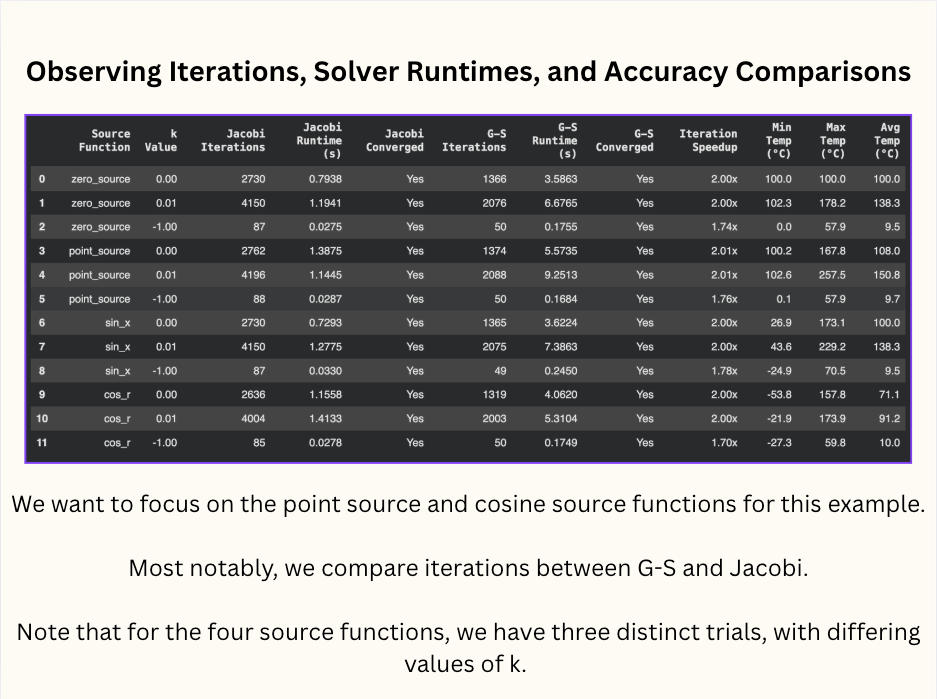

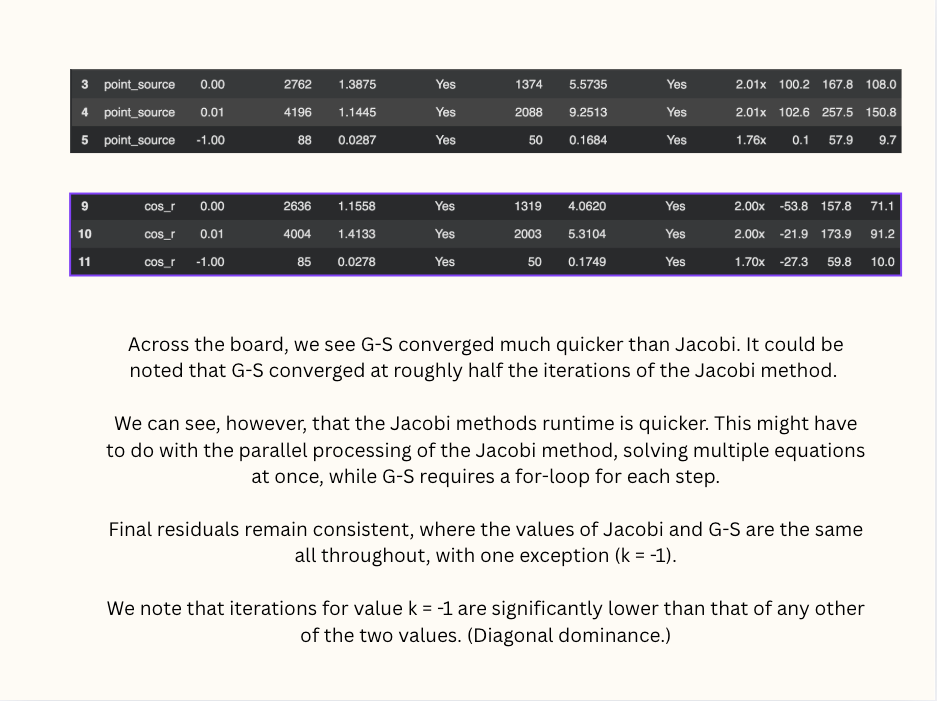

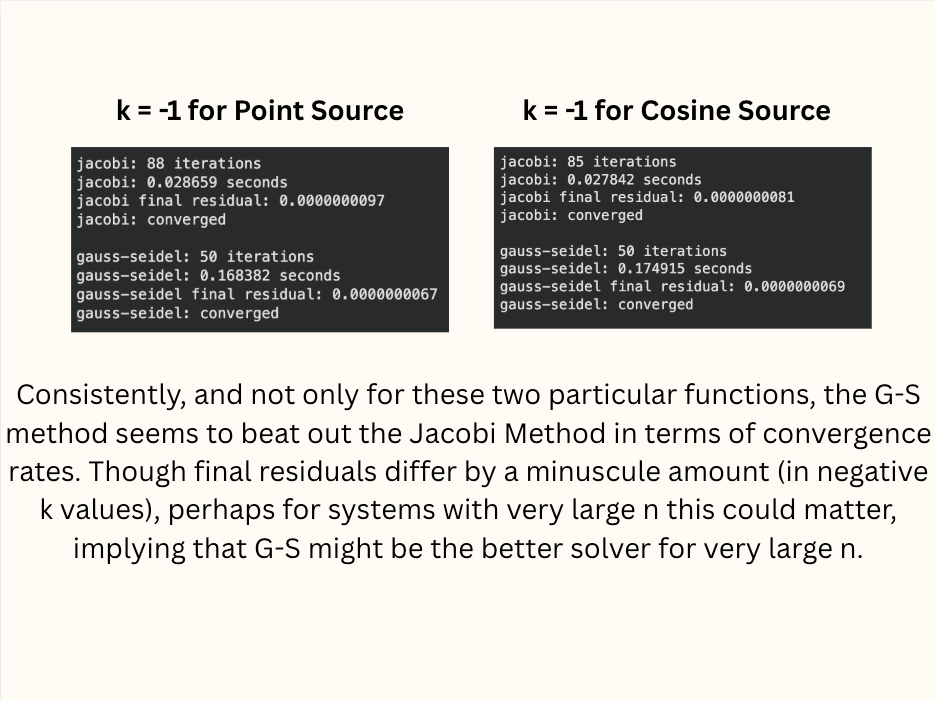

In [ ]:
print ()

## Limitations and Potential Improvements

* The accuracy of the discrete Laplacian depends on the grid spacing. The unit grid spacing we chose may be too inexact for some applications.

* There are many other iterative methods for solving linear systems, like the Richardson method and the Successive over-relaxation method which may also be used. It would be interesting to compare their convergence rates to those of the Jacobi and G-S methods.

* It would be interesting to find additional forcing functions which are physically relevant, perhaps to engineering, and apply our methods to them.

## Conclusion

* We successfully discretized and implemented two iterative methods to solve the steady-state heat equation for a variety of forcing functions f and values of k.

* We analyzed convergence rates and runtimes for each numerical experiment. The Gauss-Seidel method was found to converge in much fewer iterations than the Jacobi method for each experiment, although the Jacobi method had lower run times. Both methods produced linear plots when we graphed residuals as a function of number of iterations, showing the strong possibility of predicting convergence rates of both methods with linear regression.

* We visualized each resulting solution in order to gain intuition for physical heat diffusion processes. The experiments created interesting visual patterns and revealed the strong effects of choosing different source functions and values of k.

In [ ]:
print ()